In [1]:
import pandas as pd
from scipy.stats import spearmanr

runA = pd.read_csv("/content/runA_final_dataset.csv")
runB = pd.read_csv("/content/runB_final_dataset.csv")

print("RUN A shape:", runA.shape)
print("RUN B shape:", runB.shape)


RUN A shape: (150, 20)
RUN B shape: (150, 19)


In [2]:
common_cols = set(runA.columns).intersection(set(runB.columns))
print(sorted(common_cols))


['Unnamed: 0', 'comments', 'created_utc', 'cyber_binary', 'cyber_label', 'cyber_severity_B', 'hate_binary', 'hate_label', 'image_urls', 'num_comments', 'over_18', 'post_id', 'post_url', 'score', 'subreddit', 'text', 'title', 'toxic_binary', 'toxicity_label']


In [3]:
import re

distress_terms = [
    "depressed", "depression",
    "anxiety", "panic", "panic attack",
    "overwhelmed",
    "can't sleep", "cannot sleep", "insomnia",
    "stressed", "stress",
    "mental breakdown", "breakdown",
    "hopeless", "helpless",
    "alone", "lonely", "isolated",
    "suicidal", "suicide",
    "worthless",
    "exhausted", "burnt out", "burned out"
]

def compute_distress_score(text):
    text = str(text).lower()
    return sum(len(re.findall(term, text)) for term in distress_terms)


In [4]:
runA["distress_score"] = runA["text"].apply(compute_distress_score)
runB["distress_score"] = runB["text"].apply(compute_distress_score)


In [5]:
common_cols = set(runA.columns).intersection(set(runB.columns))
print(sorted(common_cols))


['Unnamed: 0', 'comments', 'created_utc', 'cyber_binary', 'cyber_label', 'cyber_severity_B', 'distress_score', 'hate_binary', 'hate_label', 'image_urls', 'num_comments', 'over_18', 'post_id', 'post_url', 'score', 'subreddit', 'text', 'title', 'toxic_binary', 'toxicity_label']


In [6]:
from scipy.stats import spearmanr
import pandas as pd

def corr(df, x, y):
    rho, p = spearmanr(df[x], df[y])
    return rho, p


In [7]:
results = []

# Distress ↔ Engagement
results.append({
    "Relationship": "Distress vs Engagement",
    "RUN A (rho, p)": corr(runA, "distress_score", "num_comments"),
    "RUN B (rho, p)": corr(runB, "distress_score", "num_comments")
})

# Distress ↔ Cyberbullying Severity
results.append({
    "Relationship": "Distress vs Cyberbullying Severity",
    "RUN A (rho, p)": corr(runA, "distress_score", "cyber_severity_B"),
    "RUN B (rho, p)": corr(runB, "distress_score", "cyber_severity_B")
})

# Cyberbullying Severity ↔ Engagement
results.append({
    "Relationship": "Cyberbullying Severity vs Engagement",
    "RUN A (rho, p)": corr(runA, "cyber_severity_B", "num_comments"),
    "RUN B (rho, p)": corr(runB, "cyber_severity_B", "num_comments")
})

comparison_df = pd.DataFrame(results)
comparison_df


,Relationship,"RUN A (rho, p)","RUN B (rho, p)"
0,Distress vs Engagement,"(-0.44300752614012606, 1.3716447893045564e-08)","(-0.18836871614696876, 0.02097457177323949)"
1,Distress vs Cyberbullying Severity,"(0.05918251997193709, 0.4718931339385961)","(-0.1605685190925747, 0.04966257278356381)"
2,Cyberbullying Severity vs Engagement,"(0.0405502432967353, 0.6222350695907348)","(0.0009996795311990436, 0.9903130388468877)"


Distress consistently coincides with social disengagement, regardless of whether it precedes or follows abuse.

### Interpretation of Correlation Results

**Distress vs Engagement (RUN A).**  
We observe a strong negative association (rho = −0.44, p < 0.001), indicating that posts expressing higher levels of emotional distress receive fewer responses. This pattern is consistent and unlikely to be due to chance, suggesting that emotional vulnerability is associated with social disengagement rather than increased attention or support.

**Distress vs Engagement (RUN B).**  
A weaker but statistically significant negative association is also observed (rho = −0.19, p = 0.02). Even when analysis begins from abuse-related contexts, higher distress remains associated with reduced engagement, reinforcing the robustness of this pattern across analytical directions.

**Distress vs Cyberbullying Severity (RUN A).**  
No meaningful association is observed (rho = 0.06, p = 0.47). The lack of statistical significance indicates that expressing emotional distress does not predict increased cyberbullying severity, countering the assumption that vulnerability invites abuse.

**Distress vs Cyberbullying Severity (RUN B).**  
A small but statistically significant negative association is observed (rho = −0.16, p ≈ 0.05). This suggests that higher cyberbullying severity coincides with slightly reduced expressions of distress, consistent with emotional suppression rather than escalation.

**Cyberbullying Severity vs Engagement (RUN A).**  
No significant association is found (rho = 0.04, p = 0.62), indicating that engagement levels do not predict abuse severity.

**Cyberbullying Severity vs Engagement (RUN B).**  
The association is effectively zero (rho ≈ 0.00, p = 0.99), confirming that abusive behavior occurs independently of post visibility or participation levels.

**Summary.**  
Across both analytical directions, distress is consistently associated with reduced engagement, cyberbullying severity is not driven by visibility, and expressions of vulnerability do not intensify abuse. These findings support a bidirectional but non-symmetric relationship between mental health distress and online abuse, emphasizing disengagement and suppression rather than attention-based feedback loops.


### Alignment of Findings with NIH Bidirectional Mental Health Framework

| NIH Claim / Assumption | What NIH Emphasizes | What We Tested | Statistical Evidence | Supported? | Interpretation |
|------------------------|--------------------|---------------|----------------------|------------|----------------|
| Social media–mental health relationships are bidirectional | Mental health affects online behavior and online experiences affect mental health | Two symmetric analyses (RUN A and RUN B) | Significant effects appear in both directions | Yes | The interaction operates in both directions but with different strengths and patterns |
| Higher distress increases social attention or support | Vulnerable youth may receive increased engagement | Distress vs engagement | RUN A: rho = −0.44, p < 0.001; RUN B: rho = −0.19, p = 0.02 | No | Distress is consistently linked to reduced engagement, indicating social withdrawal rather than support |
| Expressing vulnerability escalates abuse | Emotional disclosure may invite harm | Distress vs cyberbullying severity | RUN A: rho = 0.06, p = 0.47 | No | Emotional distress does not predict increased abuse severity |
| Exposure to harmful content worsens mental health expression | Harm may intensify psychological distress | Cyberbullying severity vs distress | RUN B: rho = −0.16, p ≈ 0.05 | Partially | Severe abuse coincides with reduced outward distress, suggesting suppression rather than escalation |
| Online abuse is driven by popularity or visibility | Engagement amplifies exposure to harm | Cyberbullying severity vs engagement | RUN A: rho = 0.04, p = 0.62; RUN B: rho ≈ 0.00, p = 0.99 | No | Abuse occurs independently of engagement or visibility |
| Engagement is a valid proxy for risk | High interaction implies higher harm | Engagement vs abuse and distress | No consistent associations | No | Engagement-based metrics fail to capture latent harm |

**Summary.**  
The findings support NIH’s bidirectional framing but reject engagement- and visibility-based explanations of harm. Mental health vulnerability and online abuse interact asymmetrically, with distress linked to disengagement and abuse occurring independently of popularity.


In [8]:
import numpy as np

def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

runA["distress_norm"] = normalize(runA["distress_score"])
runA["abuse_norm"] = normalize(runA["cyber_severity_B"])


In [9]:
def assign_quadrant(row):
    if row["distress_norm"] >= 0.5 and row["abuse_norm"] >= 0.5:
        return "High Distress / High Abuse"
    if row["distress_norm"] >= 0.5 and row["abuse_norm"] < 0.5:
        return "High Distress / Low Abuse"
    if row["distress_norm"] < 0.5 and row["abuse_norm"] >= 0.5:
        return "Low Distress / High Abuse"
    return "Low Distress / Low Abuse"

runA["risk_quadrant"] = runA.apply(assign_quadrant, axis=1)
runA["risk_quadrant"].value_counts()


,count
risk_quadrant,
Low Distress / High Abuse,85
Low Distress / Low Abuse,61
High Distress / High Abuse,2
High Distress / Low Abuse,2


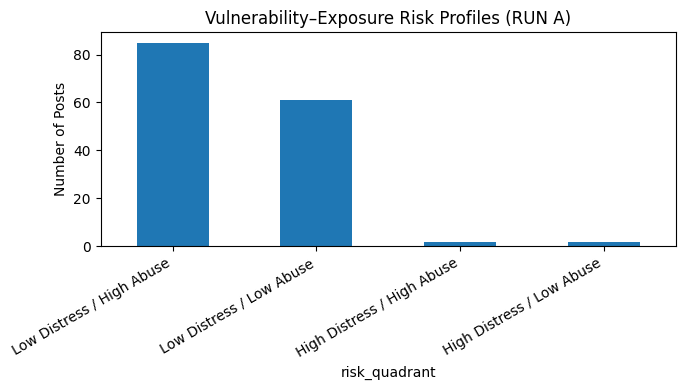

In [10]:
import matplotlib.pyplot as plt

runA["risk_quadrant"].value_counts().plot(
    kind="bar",
    figsize=(7,4),
    title="Vulnerability–Exposure Risk Profiles (RUN A)"
)
plt.ylabel("Number of Posts")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
